In [2]:
import pandas as pd
import matplotlib.pyplot as plt 
df = pd.read_csv("archive.zip")
df.head()

,Country (or dependency),Population (2020),Yearly Change,Net Change,Density (P/Km²),Land Area (Km²),Migrants (net),Fert. Rate,Med. Age,Urban Pop %,World Share
0,China,1440297825,0.39 %,5540090,153,9388211,-348399.0,1.7,38,61 %,18.47 %
1,India,1382345085,0.99 %,13586631,464,2973190,-532687.0,2.2,28,35 %,17.70 %
2,United States,331341050,0.59 %,1937734,36,9147420,954806.0,1.8,38,83 %,4.25 %
3,Indonesia,274021604,1.07 %,2898047,151,1811570,-98955.0,2.3,30,56 %,3.51 %
4,Pakistan,221612785,2.00 %,4327022,287,770880,-233379.0,3.6,23,35 %,2.83 %


In [3]:
print(df.info())
print(df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 235 entries, 0 to 234
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Country (or dependency)  235 non-null    str    
 1   Population (2020)        235 non-null    int64  
 2   Yearly Change            235 non-null    str    
 3   Net Change               235 non-null    int64  
 4   Density (P/Km²)          235 non-null    int64  
 5   Land Area (Km²)          235 non-null    int64  
 6   Migrants (net)           201 non-null    float64
 7   Fert. Rate               235 non-null    str    
 8   Med. Age                 235 non-null    str    
 9   Urban Pop %              235 non-null    str    
 10  World Share              235 non-null    str    
dtypes: float64(1), int64(4), str(6)
memory usage: 20.3 KB
None
Country (or dependency)     0
Population (2020)           0
Yearly Change               0
Net Change                  0
Density (P/Km²)     

In [4]:
df = df.dropna()
df.isnull().sum()

Country (or dependency)    0
Population (2020)          0
Yearly Change              0
Net Change                 0
Density (P/Km²)            0
Land Area (Km²)            0
Migrants (net)             0
Fert. Rate                 0
Med. Age                   0
Urban Pop %                0
World Share                0
dtype: int64

In [5]:
df['Yearly Change'] = df['Yearly Change'].str.replace("%","")
df["Urban Pop %"] = df["Urban Pop %"].str.replace("%","")
df["World Share"] = df["World Share"].str.replace("%", "")
df["Yearly Change"] = pd.to_numeric(df["Yearly Change"], errors="coerce")
df["Fert. Rate"] = pd.to_numeric(df["Fert. Rate"], errors="coerce")
df["Med. Age"] = pd.to_numeric(df["Med. Age"], errors="coerce")
df["Urban Pop %"] = pd.to_numeric(df["Urban Pop %"], errors="coerce")
df["World Share"] = pd.to_numeric(df["World Share"], errors = "coerce")



In [6]:
df["Yearly Change"] = df["Yearly Change"].astype(float)
df["Urban Pop %"] = df["Urban Pop %"].astype(float)
df["Fert. Rate"] =df['Fert. Rate'].astype(float)
df["World Share"] = df["World Share"].astype(float)
df["Med. Age"] = df["Med. Age"].astype(float)

In [7]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 201 entries, 0 to 200
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Country (or dependency)  201 non-null    str    
 1   Population (2020)        201 non-null    int64  
 2   Yearly Change            201 non-null    float64
 3   Net Change               201 non-null    int64  
 4   Density (P/Km²)          201 non-null    int64  
 5   Land Area (Km²)          201 non-null    int64  
 6   Migrants (net)           201 non-null    float64
 7   Fert. Rate               201 non-null    float64
 8   Med. Age                 201 non-null    float64
 9   Urban Pop %              194 non-null    float64
 10  World Share              201 non-null    float64
dtypes: float64(6), int64(4), str(1)
memory usage: 17.4 KB
None


In [8]:
top_10 = df.sort_values(by="Population (2020)", ascending = False).head(10)
print(top_10)




  Country (or dependency)  Population (2020)  Yearly Change  Net Change  \
0                   China         1440297825           0.39     5540090   
1                   India         1382345085           0.99    13586631   
2           United States          331341050           0.59     1937734   
3               Indonesia          274021604           1.07     2898047   
4                Pakistan          221612785           2.00     4327022   
5                  Brazil          212821986           0.72     1509890   
6                 Nigeria          206984347           2.58     5175990   
7              Bangladesh          164972348           1.01     1643222   
8                  Russia          145945524           0.04       62206   
9                  Mexico          129166028           1.06     1357224   

   Density (P/Km²)  Land Area (Km²)  Migrants (net)  Fert. Rate  Med. Age  \
0              153          9388211       -348399.0         1.7      38.0   
1              464  

In [9]:
top_10_chart = top_10.sort_values(by = "Population (2020)", ascending = True)
print(top_10_chart)

  Country (or dependency)  Population (2020)  Yearly Change  Net Change  \
9                  Mexico          129166028           1.06     1357224   
8                  Russia          145945524           0.04       62206   
7              Bangladesh          164972348           1.01     1643222   
6                 Nigeria          206984347           2.58     5175990   
5                  Brazil          212821986           0.72     1509890   
4                Pakistan          221612785           2.00     4327022   
3               Indonesia          274021604           1.07     2898047   
2           United States          331341050           0.59     1937734   
1                   India         1382345085           0.99    13586631   
0                   China         1440297825           0.39     5540090   

   Density (P/Km²)  Land Area (Km²)  Migrants (net)  Fert. Rate  Med. Age  \
9               66          1943950        -60000.0         2.1      29.0   
8                9  

Text(0.5, 1.0, 'Top 10 Most Populated Countries (2020)')

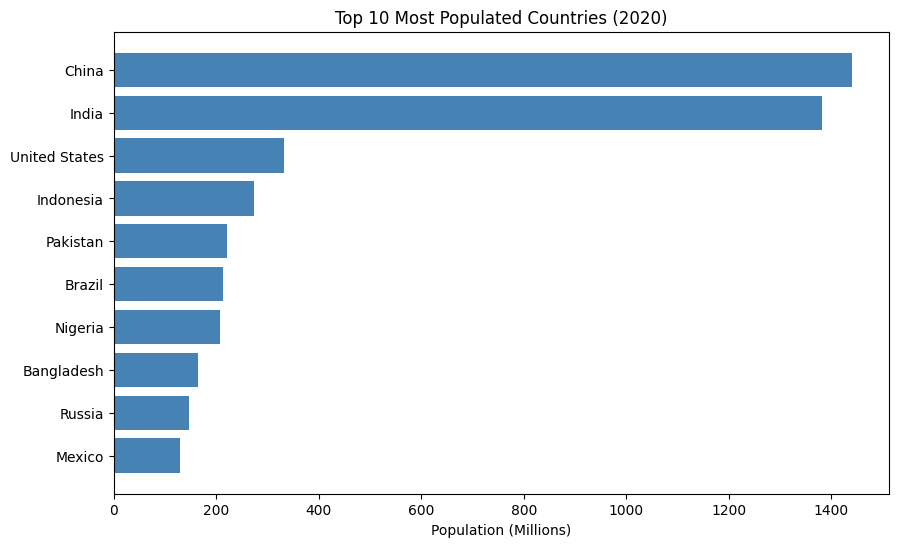

In [10]:
plt.figure(figsize = (10, 6))


# divide the population by 1,000,000 so the chart says "1,440" instead of "1,440,000,000"
plt.barh(top_10_chart["Country (or dependency)"], top_10_chart['Population (2020)'] / 1_000_000, color='steelblue')

plt.xlabel('Population (Millions)')
plt.title('Top 10 Most Populated Countries (2020)')


    Country (or dependency)  Population (2020)  Yearly Change  Net Change  \
55                    Niger           24346468           3.84      895929   
151                 Bahrain            1711057           3.68       60403   
152       Equatorial Guinea            1410419           3.47       46999   
30                   Uganda           45974931           3.32     1471413   
43                   Angola           33032075           3.27     1040977   
15                 DR Congo           90003954           3.19     2770836   
77                  Burundi           11948454           3.12      360204   
59                     Mali           20346106           3.02      592802   
71                     Chad           16502877           3.00      478988   
23                 Tanzania           60012400           2.98     1728755   

     Density (P/Km²)  Land Area (Km²)  Migrants (net)  Fert. Rate  Med. Age  \
55                19          1266700          4000.0         7.0      15

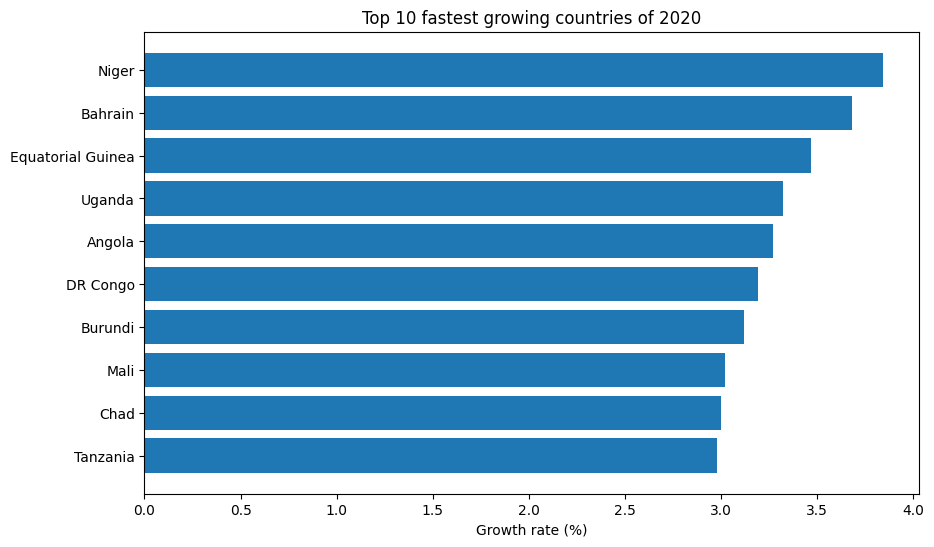

In [11]:
top10_fastest_growing = df.sort_values(by= "Yearly Change", ascending= False).head(10)
print(top10_fastest_growing)
top10_fastest_growing_chart = top10_fastest_growing.sort_values(by= "Yearly Change", ascending= True)


plt.figure(figsize= (10, 6))
plt.barh(top10_fastest_growing_chart["Country (or dependency)"], top10_fastest_growing_chart["Yearly Change"])
plt.xlabel("Growth rate (%)")
plt.title("Top 10 fastest growing countries of 2020")
plt.show()

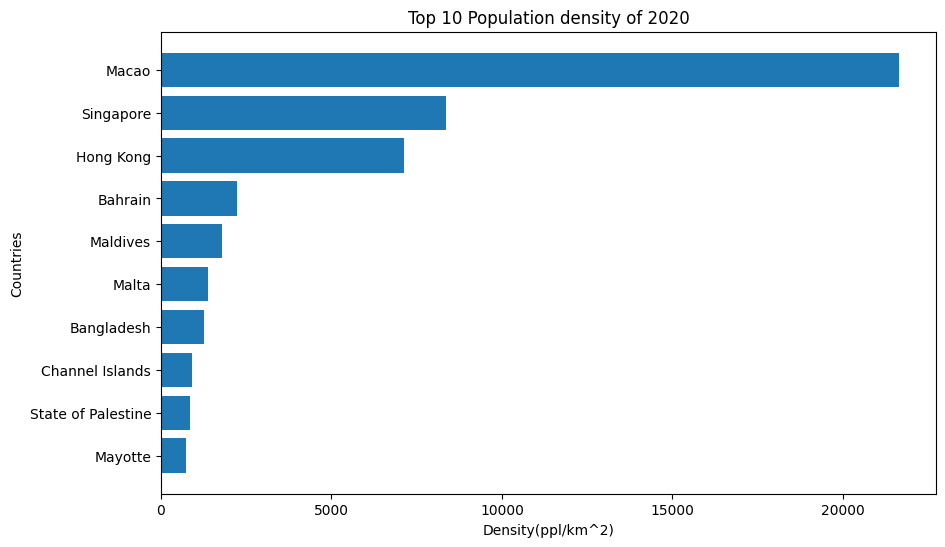

In [ ]:
top_10_pd = df.sort_values(by = "Density (P/Km²)", ascending=False).head(10)
top_10_pd_chart = top_10_pd.sort_values(by = "Density (P/Km²)", ascending = True)

plt.figure(figsize= (10, 6))
plt.barh(top_10_pd_chart["Country (or dependency)"], top_10_pd_chart["Density (P/Km²)"])
plt.xlabel("Density(ppl/km^2)")
plt.ylabel("Countries")
plt.title("Top 10 Population density of 2020")
plt.show()

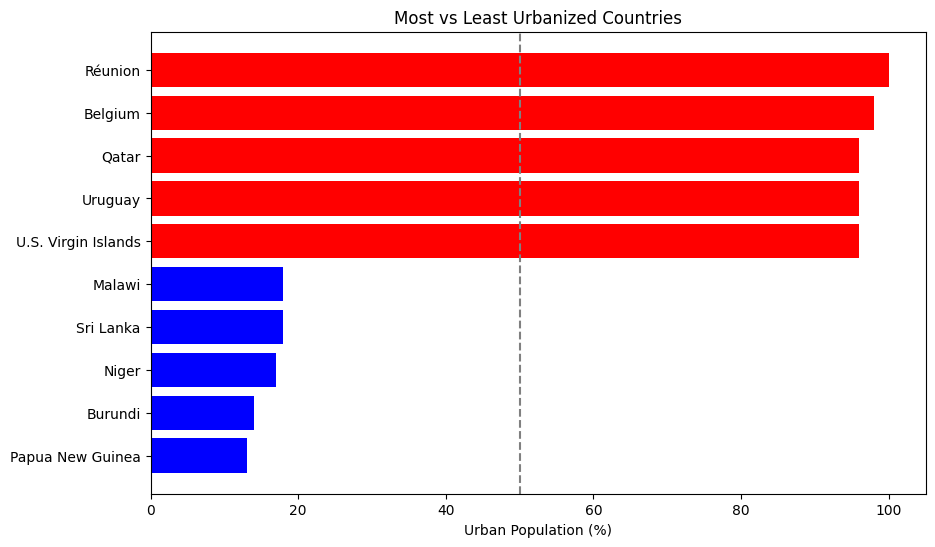

In [13]:
top5_urban_pop = df.sort_values(by = "Urban Pop %", ascending= False).head(5)
least5_urban_pop = df.sort_values(by = "Urban Pop %", ascending=True).head(5)
urban_combined = pd.concat([top5_urban_pop, least5_urban_pop])
urban_combined = urban_combined.sort_values(by = "Urban Pop %", ascending= True)

plt.figure(figsize = (10, 6))
colors = ['red' if v > 50 else 'blue' for v in urban_combined['Urban Pop %']]
plt.barh(urban_combined["Country (or dependency)"], urban_combined["Urban Pop %"], color = colors)
plt.axvline(50, color='gray', linestyle='--')

plt.xlabel("Urban Population (%)")
plt.title("Most vs Least Urbanized Countries")
plt.show()

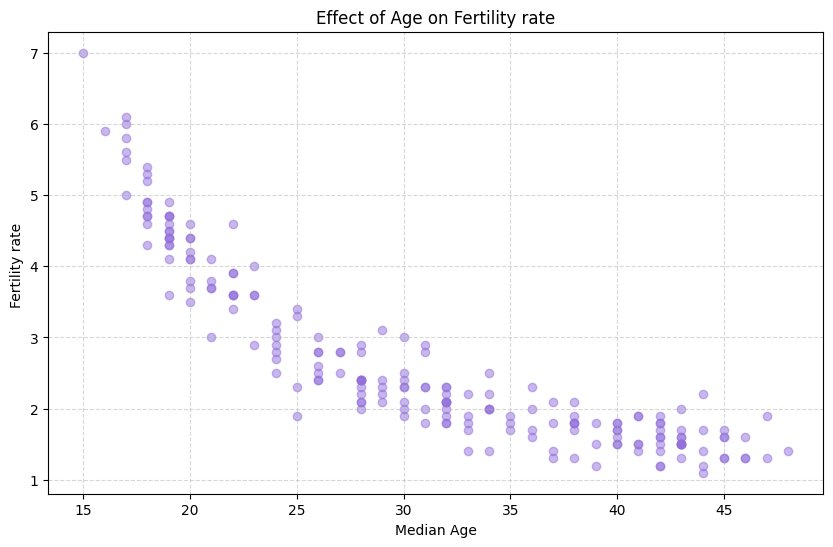

In [21]:
plt.figure(figsize= (10, 6))
plt.scatter(df["Med. Age"], df["Fert. Rate"], alpha = 0.5, color = "mediumpurple")
plt.xlabel("Median Age")
plt.ylabel("Fertility rate ")
plt.title("Effect of Age on Fertility rate")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

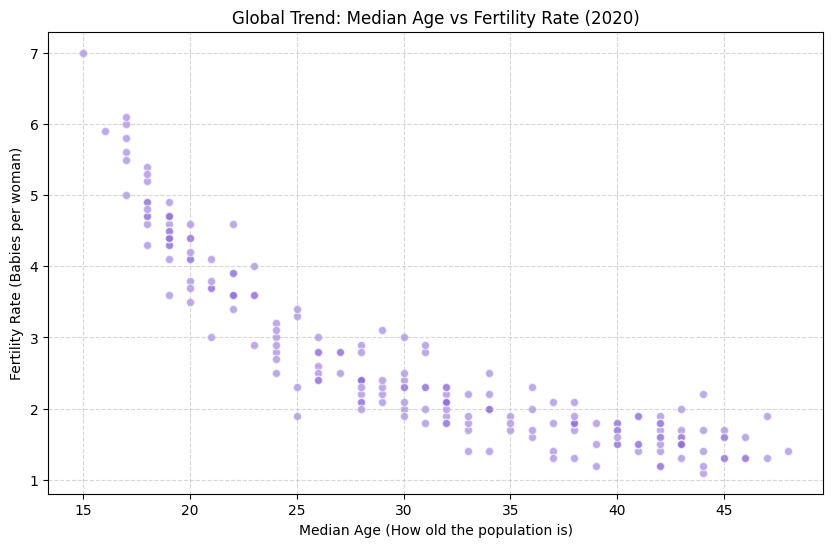

In [15]:
plt.figure(figsize=(10, 6))

# Plotting the raw relationship
plt.scatter(df['Med. Age'], df['Fert. Rate'], 
            color='mediumpurple', 
            alpha=0.6, 
            edgecolors='white')

# Labels and Title
plt.xlabel('Median Age (How old the population is)')
plt.ylabel('Fertility Rate (Babies per woman)')
plt.title('Global Trend: Median Age vs Fertility Rate (2020)')

# Optional: Add a grid so you can see where countries land more easily
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

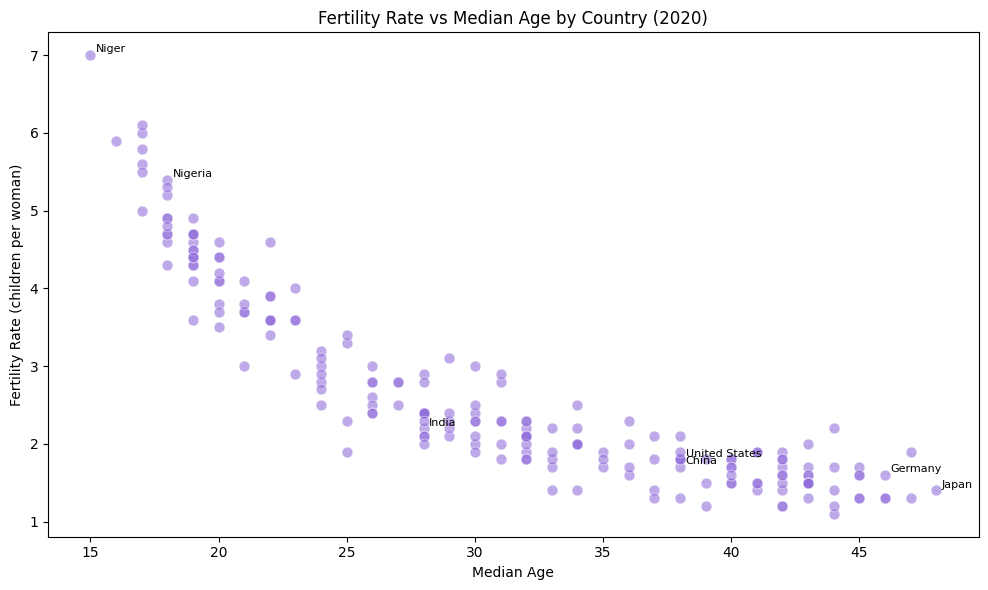

Task 5 done ✅

🎉 All 5 tasks complete! 5 charts saved.


In [ ]:
scatter_df = df.dropna(subset=['Fert. Rate', 'Med. Age'])
plt.figure(figsize=(10, 6))
plt.scatter(scatter_df['Med. Age'], scatter_df['Fert. Rate'],
            alpha=0.6, edgecolors='white', linewidth=0.5,
            color='mediumpurple', s=60)

# Label a few interesting countries
for _, row in scatter_df.iterrows():
    if row['Country (or dependency)'] in ['Niger', 'Japan', 'Germany', 'Nigeria', 'United States', 'India', 'China']:
        plt.annotate(row['Country (or dependency)'],
                     xy=(row['Med. Age'], row['Fert. Rate']),
                     fontsize=8, ha='left',
                     xytext=(4, 2), textcoords='offset points')

plt.xlabel('Median Age')
plt.ylabel('Fertility Rate (children per woman)')
plt.title('Fertility Rate vs Median Age by Country (2020)')
plt.tight_layout()
plt.savefig('task5_fertility_vs_age.png', dpi=150)
plt.show()
